In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "src").exists() and PROJECT_ROOT != PROJECT_ROOT.parent:
	PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.append(str(PROJECT_ROOT))
sys.path.append(str(PROJECT_ROOT / "src"))

import dataset
import model
import train
import evaluate

import torch
from torchvision import transforms

In [2]:
bodyM_path = Path("../data/BodyM")
testA_data = Path(bodyM_path / "testA")
testB_data = Path(bodyM_path / "testB")
train_data = Path(bodyM_path / "train")

In [3]:
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ToTensor(),
])

In [4]:
testA_dataset = dataset.BodyMDataset(testA_data)
testB_dataset = dataset.BodyMDataset(testB_data)
train_dataset = dataset.BodyMDataset(train_data, transform=train_transform)

In [5]:
vision_model = model.BodyM_EfficientNet(output_size=14)

In [6]:
torch.cuda.is_available()  # Check if CUDA is available

True

In [7]:
print(len(train_dataset))

6134


In [8]:
trained_model, history = train.train_vision_model(vision_model, train_dataset, testA_dataset, epochs = 100)

Epoch   1 | train_loss: 0.9379 | val_loss: 0.7920 | val_mae: 0.6925
Epoch   2 | train_loss: 0.7261 | val_loss: 0.7082 | val_mae: 0.6445
Epoch   3 | train_loss: 0.6097 | val_loss: 0.5915 | val_mae: 0.5933
Epoch   4 | train_loss: 0.5536 | val_loss: 0.5854 | val_mae: 0.5904
Epoch   5 | train_loss: 0.5424 | val_loss: 0.5690 | val_mae: 0.5842
Epoch   6 | train_loss: 0.5200 | val_loss: 0.5418 | val_mae: 0.5723
Epoch   7 | train_loss: 0.5016 | val_loss: 0.5289 | val_mae: 0.5665
Epoch   8 | train_loss: 0.4958 | val_loss: 0.5611 | val_mae: 0.5818
Epoch   9 | train_loss: 0.4906 | val_loss: 0.5836 | val_mae: 0.5938
Epoch  10 | train_loss: 0.4824 | val_loss: 0.5681 | val_mae: 0.5848
Epoch  11 | train_loss: 0.4756 | val_loss: 0.5464 | val_mae: 0.5744
Epoch  12 | train_loss: 0.4698 | val_loss: 0.6073 | val_mae: 0.6060
Epoch  13 | train_loss: 0.4687 | val_loss: 0.5367 | val_mae: 0.5706
Epoch  14 | train_loss: 0.4569 | val_loss: 0.5513 | val_mae: 0.5790
Epoch  15 | train_loss: 0.4593 | val_loss: 0.539

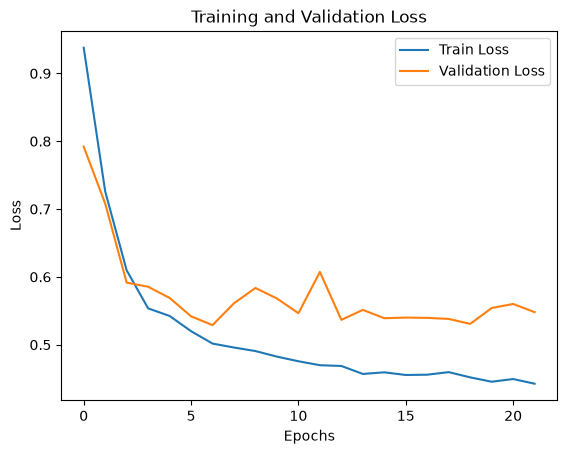

In [9]:
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

In [10]:
trained_model.eval()  
testA_loader = torch.utils.data.DataLoader(testA_dataset, batch_size=32, shuffle=False)
metrics, preds, targets = evaluate.evaluate_vision_model(trained_model, testA_loader, target_mean = train_dataset.target_mean, target_std = train_dataset.target_std)

In [11]:
print(metrics)

{'ankle': {'mae': np.float32(1.0938768), 'mse': np.float32(2.0409214), 'rmse': np.float32(1.4286082), 'r2': np.float32(0.41529506)}, 'arm-length': {'mae': np.float32(2.1271126), 'mse': np.float32(7.476547), 'rmse': np.float32(2.7343276), 'r2': np.float32(0.28983772)}, 'bicep': {'mae': np.float32(2.2759926), 'mse': np.float32(8.522902), 'rmse': np.float32(2.919401), 'r2': np.float32(0.48388815)}, 'calf': {'mae': np.float32(2.1816168), 'mse': np.float32(8.063631), 'rmse': np.float32(2.8396533), 'r2': np.float32(0.23903418)}, 'chest': {'mae': np.float32(5.778572), 'mse': np.float32(53.65512), 'rmse': np.float32(7.3249655), 'r2': np.float32(0.5887654)}, 'forearm': {'mae': np.float32(1.5370548), 'mse': np.float32(3.6489213), 'rmse': np.float32(1.910215), 'r2': np.float32(0.50567365)}, 'height': {'mae': np.float32(5.972677), 'mse': np.float32(57.728607), 'rmse': np.float32(7.5979342), 'r2': np.float32(0.3708132)}, 'hip': {'mae': np.float32(4.9992294), 'mse': np.float32(43.166504), 'rmse': np

Text(0, 0.5, 'Predictions')

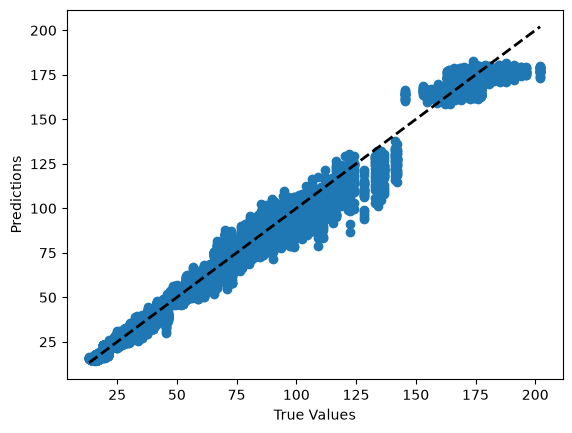

In [12]:
plt.scatter(targets, preds)
plt.plot([targets.min(), targets.max()], [targets.min(), targets.max()], 'k--', lw=2)
plt.xlabel('True Values')
plt.ylabel('Predictions')

In [13]:
"""
for i in range(14):
    plt.figure()
    plt.scatter(targets[:, i], preds[:, i])
    plt.plot([targets[:, i].min(), targets[:, i].max()], [targets[:, i].min(), targets[:, i].max()], 'k--', lw=2)
    plt.xlabel('True Values')
    plt.ylabel('Predictions')
    plt.title(f'Target {i+1}')
    plt.show()
"""

"\nfor i in range(14):\n    plt.figure()\n    plt.scatter(targets[:, i], preds[:, i])\n    plt.plot([targets[:, i].min(), targets[:, i].max()], [targets[:, i].min(), targets[:, i].max()], 'k--', lw=2)\n    plt.xlabel('True Values')\n    plt.ylabel('Predictions')\n    plt.title(f'Target {i+1}')\n    plt.show()\n"

Partial Unfreezing (didn't help with overfitting so keeping only phase 1 for now)

In [14]:
'''
for param in trained_model.model.features[-2:].parameters():
    param.requires_grad = True

filtered_params = [p for p in trained_model.parameters() if p.requires_grad]

trained_model, history = train.train_vision_model(trained_model, train_dataset, testA_dataset, epochs = 100, lr=1e-5, weight_decay=1e-5)
'''

'\nfor param in trained_model.model.features[-2:].parameters():\n    param.requires_grad = True\n\nfiltered_params = [p for p in trained_model.parameters() if p.requires_grad]\n\ntrained_model, history = train.train_vision_model(trained_model, train_dataset, testA_dataset, epochs = 100, lr=1e-5, weight_decay=1e-5)\n'

In [15]:
'''
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
'''

"\nplt.plot(history['train_loss'], label='Train Loss')\nplt.plot(history['val_loss'], label='Validation Loss')\nplt.title('Training and Validation Loss')\nplt.xlabel('Epochs')\nplt.ylabel('Loss')\nplt.legend()\n"

In [16]:
'''
trained_model.eval()  
testA_loader = torch.utils.data.DataLoader(testA_dataset, batch_size=32, shuffle=False)
metrics, preds, targets = evaluate.evaluate_vision_model(trained_model, testA_loader, target_mean = train_dataset.target_mean, target_std = train_dataset.target_std)
print(metrics)
'''

'\ntrained_model.eval()  \ntestA_loader = torch.utils.data.DataLoader(testA_dataset, batch_size=32, shuffle=False)\nmetrics, preds, targets = evaluate.evaluate_vision_model(trained_model, testA_loader, target_mean = train_dataset.target_mean, target_std = train_dataset.target_std)\nprint(metrics)\n'

In [17]:
torch.save({
    "model_state_dict": trained_model.state_dict(),
    "in_channels": 2,
    "dropout_rate": 0.2,
    "output_size": 14,
    "target_mean": train_dataset.target_mean,
    "target_std": train_dataset.target_std,
    "measurement_cols": train_dataset.measurement_cols,
}, "../checkpoints/bodym_efficientnet.pt")